In [ ]:
# Day 5 - Data Cleaning on Messy Employee Dataset

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('Messy_Employee_dataset.csv')
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


In [5]:
df.shape

(1020, 12)

In [6]:
df.columns

Index(['Employee_ID', 'First_Name', 'Last_Name', 'Age', 'Department_Region',
       'Status', 'Join_Date', 'Salary', 'Email', 'Phone', 'Performance_Score',
       'Remote_Work'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        1020 non-null   object 
 1   First_Name         1020 non-null   object 
 2   Last_Name          1020 non-null   object 
 3   Age                809 non-null    float64
 4   Department_Region  1020 non-null   object 
 5   Status             1020 non-null   object 
 6   Join_Date          1020 non-null   object 
 7   Salary             996 non-null    float64
 8   Email              1020 non-null   object 
 9   Phone              1020 non-null   int64  
 10  Performance_Score  1020 non-null   object 
 11  Remote_Work        1020 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(8)
memory usage: 88.8+ KB


In [8]:
df.describe(include='all')

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
count,1020,1020,1020,809.000000,1020,1020,1020,996.000000,1020,1.020000e+03,1020,1020
unique,1020,8,8,NaN,36,3,760,NaN,64,NaN,4,2
top,EMP1000,Frank,Brown,NaN,HR-Florida,Pending,6/10/2024,NaN,grace.brown@example.com,NaN,Good,True
freq,1,142,148,NaN,41,356,5,NaN,27,NaN,270,513
mean,NaN,NaN,NaN,32.484549,NaN,NaN,NaN,85155.056396,NaN,-4.942253e+09,NaN,NaN
std,NaN,NaN,NaN,5.656860,NaN,NaN,NaN,19873.727918,NaN,2.817326e+09,NaN,NaN
min,NaN,NaN,NaN,25.000000,NaN,NaN,NaN,50047.320000,NaN,-9.994973e+09,NaN,NaN
25%,NaN,NaN,NaN,25.000000,NaN,NaN,NaN,68392.487500,NaN,-7.341992e+09,NaN,NaN
50%,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,85547.870000,NaN,-4.943997e+09,NaN,NaN
75%,NaN,NaN,NaN,40.000000,NaN,NaN,NaN,100974.027500,NaN,-2.520391e+09,NaN,NaN


In [9]:
df.isnull().sum()

Employee_ID            0
First_Name             0
Last_Name              0
Age                  211
Department_Region      0
Status                 0
Join_Date              0
Salary                24
Email                  0
Phone                  0
Performance_Score      0
Remote_Work            0
dtype: int64

In [10]:
missing_percent = (df.isnull().sum()/len(df))*100
missing_percent.sort_values(ascending=False)

Age                  20.686275
Salary                2.352941
Employee_ID           0.000000
First_Name            0.000000
Last_Name             0.000000
Department_Region     0.000000
Status                0.000000
Join_Date             0.000000
Email                 0.000000
Phone                 0.000000
Performance_Score     0.000000
Remote_Work           0.000000
dtype: float64

In [11]:
# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Salary'] = df['Salary'].fillna(df['Salary'].median())
df.isnull().sum()

Employee_ID          0
First_Name           0
Last_Name            0
Age                  0
Department_Region    0
Status               0
Join_Date            0
Salary               0
Email                0
Phone                0
Performance_Score    0
Remote_Work          0
dtype: int64

In [12]:
df.duplicated().sum()

0

In [13]:
# Remove duplicate rows
df = df.drop_duplicates()
df.duplicated().sum()

0

In [14]:
df.dtypes

Employee_ID           object
First_Name            object
Last_Name             object
Age                  float64
Department_Region     object
Status                object
Join_Date             object
Salary               float64
Email                 object
Phone                  int64
Performance_Score     object
Remote_Work             bool
dtype: object

In [15]:
# Data type cleaning
df['Join_Date'] = pd.to_datetime(df['Join_Date'], errors='coerce')
df['First_Name'] = df['First_Name'].str.title().str.strip()
df['Last_Name'] = df['Last_Name'].str.title().str.strip()
df['Department_Region'] = df['Department_Region'].str.strip()
df['Status'] = df['Status'].str.strip().str.title()
df['Performance_Score'] = df['Performance_Score'].str.strip().str.title()
df.dtypes

Employee_ID                  object
First_Name                   object
Last_Name                    object
Age                         float64
Department_Region            object
Status                       object
Join_Date            datetime64[ns]
Salary                      float64
Email                        object
Phone                         int64
Performance_Score            object
Remote_Work                    bool
dtype: object

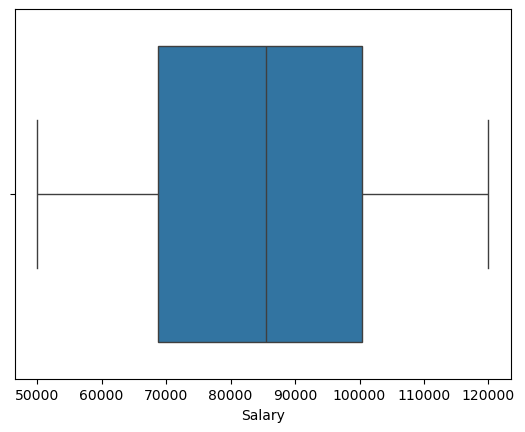

In [16]:
# Outlier detection for Salary
sns.boxplot(x=df['Salary'])
plt.show()

In [17]:
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
lower, upper

(21469.087499999987, 147714.80750000002)

In [24]:
outliers = df[(df['Salary'] < lower) | (df['Salary'] > upper)]
outliers.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work


In [19]:
# Remove outliers
df = df[(df['Salary'] >= lower) & (df['Salary'] <= upper)]
df.shape

(1020, 12)

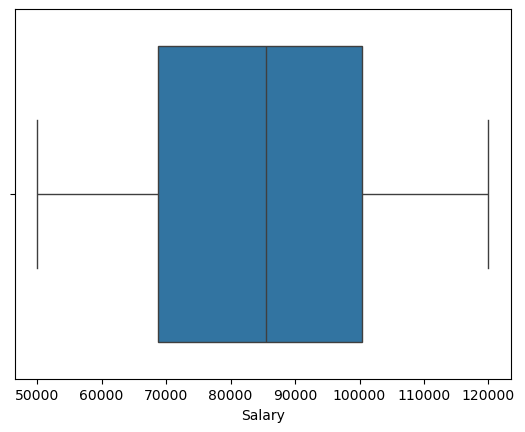

In [20]:
sns.boxplot(x=df['Salary'])
plt.show()

In [21]:
# Final dataset summary
df.isnull().sum()
df.dtypes
df.shape
df.describe(include='all')

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
count,1020,1020,1020,1020.000000,1020,1020,1020,1020.000000,1020,1.020000e+03,1020,1020
unique,1020,8,8,NaN,36,3,NaN,NaN,64,NaN,4,2
top,EMP1000,Frank,Brown,NaN,HR-Florida,Pending,NaN,NaN,grace.brown@example.com,NaN,Good,True
freq,1,142,148,NaN,41,356,NaN,NaN,27,NaN,270,513
mean,NaN,NaN,NaN,31.970588,NaN,NaN,2022-07-26 12:53:38.823529472,85164.299069,NaN,-4.942253e+09,NaN,NaN
min,NaN,NaN,NaN,25.000000,NaN,NaN,2020-01-01 00:00:00,50047.320000,NaN,-9.994973e+09,NaN,NaN
25%,NaN,NaN,NaN,30.000000,NaN,NaN,2021-04-12 06:00:00,68811.232500,NaN,-7.341992e+09,NaN,NaN
50%,NaN,NaN,NaN,30.000000,NaN,NaN,2022-08-09 12:00:00,85547.870000,NaN,-4.943997e+09,NaN,NaN
75%,NaN,NaN,NaN,35.000000,NaN,NaN,2023-10-31 12:00:00,100372.662500,NaN,-2.520391e+09,NaN,NaN
max,NaN,NaN,NaN,40.000000,NaN,NaN,2024-12-29 00:00:00,119971.650000,NaN,-3.896086e+06,NaN,NaN


In [25]:
# Save cleaned dataset
df.to_csv('Messy_Employee_dataset_cleaned.csv', index=False)

In [23]:
# Reusable data quality report
def data_quality_report(df):
    report = {
        'shape': df.shape,
        'missing_values': df.isnull().sum(),
        'duplicate_rows': df.duplicated().sum(),
        'dtypes': df.dtypes
    }
    return report

data_quality_report(df)

{'shape': (1020, 12),
 'missing_values': Employee_ID          0
 First_Name           0
 Last_Name            0
 Age                  0
 Department_Region    0
 Status               0
 Join_Date            0
 Salary               0
 Email                0
 Phone                0
 Performance_Score    0
 Remote_Work          0
 dtype: int64,
 'duplicate_rows': 0,
 'dtypes': Employee_ID                  object
 First_Name                   object
 Last_Name                    object
 Age                         float64
 Department_Region            object
 Status                       object
 Join_Date            datetime64[ns]
 Salary                      float64
 Email                        object
 Phone                         int64
 Performance_Score            object
 Remote_Work                    bool
 dtype: object}